# Validacion del Permutation Test (MCPT) sobre S&P 500

**Objetivo:** mostrar empiricamente que el Monte Carlo Permutation Test detecta correctamente la presencia o ausencia de senal predictiva, usando modelos donde la verdad es conocida.

## Los tres modelos

| Modelo | Que hace | p-value esperado IS | p-value esperado WF |
|---|---|---|---|
| **Oraculo + ruido** | Ve el target real con ruido gaussiano controlado | bajo (~0) | bajo (~0) |
| **LightGBM overfit** | Gradient boosting con muchas features tecnicas | **muy bajo IS** | **alto WF** |
| **Random puro** | Predice +/-1 al azar | alto (uniforme) | alto (uniforme) |

## Diseno experimental

- **Activo:** S&P 500 (SPY) diario, desde 2000.
- **Target:** signo del retorno log al dia siguiente.
- **Permutacion:** del target `y` (Y-permutation), siguiendo Masters para modelos predictivos. Rompe el link X->y sin tocar la correlacion intra-X.
- **Estadistico:** Profit Factor (suma de PnL positivo / |suma de PnL negativo|).
- **p-value:** `(k+1)/(m+1)` donde k = #permutaciones con PF >= real.

## Tests

1. **IS MCPT:** entrena con todos los datos, mide PF in-sample. Detecta overfitting.
2. **WF MCPT:** re-entrena en ventana movil, mide PF OOS concatenado. Detecta si el factory produce sistemas genuinos.

## Setup

In [64]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from tqdm.auto import tqdm
from joblib import Parallel, delayed

sns.reset_defaults()
sns.set_palette('deep', 10)
import matplotlib as mpl
_COLORS = [c['color'] for c in mpl.rcParams['axes.prop_cycle']]

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})

RNG_SEED = 67
np.random.seed(RNG_SEED)

In [65]:
N_PERM       = 200          # numero de permutaciones por test
TRAIN_WINDOW = 252 * 8      # 8 anos de training para WF (mas amplio)
WF_STEP      = 63           # re-entrenar cada ~3 meses
ORACLE_NOISE = 1.0          # std del ruido gaussiano sumado al target del oraculo
                            # mas chico = oraculo mas fuerte. 1.0 da senal moderada.
N_JOBS       = 8            # workers paralelos (joblib) para correr permutaciones
REAL_SEED    = 7            # seed del modelo random/oraculo en la corrida REAL.
                            # Cambiarlo es como cambiar el draw del experimento.
                            # Bajo H0 el p-value del random varia uniforme en [0,1].

## Datos: S&P 500

Descargamos SPY (proxy del S&P 500) y construimos features tecnicas. El target es el signo del retorno log al dia siguiente.

In [66]:
print('Descargando SPY...')
spy = yf.download('SPY', start='2000-01-01', auto_adjust=True, progress=False)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.droplevel(1)
spy.columns = [c.capitalize() for c in spy.columns]
print(f'SPY: {len(spy)} barras desde {spy.index[0].date()} hasta {spy.index[-1].date()}')

Descargando SPY...
SPY: 6632 barras desde 2000-01-03 hasta 2026-05-15


In [67]:
def build_features(ohlcv: pd.DataFrame):
    """Construye un set amplio de features tecnicas. Suficiente capacidad
    para que LightGBM pueda overfittear si hay ruido que ajustar."""
    df = pd.DataFrame(index=ohlcv.index)
    close = ohlcv['Close']
    open_ = ohlcv['Open']
    high  = ohlcv['High']
    low   = ohlcv['Low']
    vol   = ohlcv['Volume']

    log_close = np.log(close)
    log_ret   = log_close.diff()

    # Retornos a varios horizontes
    for n in [1, 2, 3, 5, 10, 21, 63]:
        df[f'ret_{n}d'] = log_close.diff(n)

    # Ratios de precio sobre medias moviles
    for n in [10, 20, 50, 100, 200]:
        df[f'price_ma{n}_ratio'] = close / close.rolling(n).mean() - 1

    # Volatilidad realizada
    for n in [5, 10, 21, 63]:
        df[f'rvol_{n}d'] = log_ret.rolling(n).std() * np.sqrt(252)

    # Ratio de volatilidad corta/larga
    df['vol_ratio'] = df['rvol_5d'] / (df['rvol_63d'] + 1e-9)

    # ATR normalizado
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs(),
    ], axis=1).max(axis=1)
    df['atr_norm_14d'] = tr.rolling(14).mean() / close

    # Estructura intradia
    df['candle_body'] = (close - open_) / close
    df['gap']         = (open_ - close.shift()) / close.shift()
    df['hl_range']    = (high - low) / close

    # Volumen relativo
    df['rel_volume'] = vol / vol.rolling(20).mean()

    # Momentos
    df['skew_21d'] = log_ret.rolling(21).skew()
    df['kurt_21d'] = log_ret.rolling(21).kurt()
    df['skew_63d'] = log_ret.rolling(63).skew()

    # Calendario
    df['day_of_week'] = ohlcv.index.dayofweek.astype(float)
    df['month']       = ohlcv.index.month.astype(float)

    # Target: signo del retorno log siguiente
    target = np.sign(log_close.shift(-1) - log_close).replace(0, 1)
    df['_target'] = target
    df = df.dropna()

    return df.drop(columns=['_target']), df['_target']


X_full, y = build_features(spy)
log_ret_next = np.log(spy['Close']).diff().shift(-1).reindex(X_full.index)

# X_is: solo OHLC crudos (open, high, low, close). Sin features derivadas y sin
# volume (corr +0.32 con |ret_next|). Las features derivadas (rvol, MAs, etc.)
# correlacionan con la magnitud del retorno futuro, lo que bajo Y-permutation
# le da una ventaja injusta a la corrida real (Masters lin. 296-303). Con OHLC
# crudo esa correlacion es minima (~-0.08) y el test funciona casi sin sesgo.
X_is = pd.DataFrame({
    'open':  spy['Open'],
    'high':  spy['High'],
    'low':   spy['Low'],
    'close': spy['Close'],
}, index=spy.index).reindex(X_full.index)

X_wf = X_full

print(f'Filas: {len(X_full)}')
print(f'X_wf (WF/OOS): {X_wf.shape[1]} features')
print(f'X_is (IS):     {X_is.shape[1]} features = {list(X_is.columns)}')
print(f'Balance del target: {(y == 1).mean():.3f} long, {(y == -1).mean():.3f} short')

Filas: 6432
X_wf (WF/OOS): 27 features
X_is (IS):     4 features = ['open', 'high', 'low', 'close']
Balance del target: 0.550 long, 0.450 short


## Los tres modelos

Cada modelo expone la misma interfaz: dado `X` (e idealmente `y` para entrenar), devuelve una `Series` de senales en `{-1, +1}`.

### Modelo 1 — Oraculo + ruido

Ve el target real, le suma ruido gaussiano y devuelve el signo. Controla la fuerza de la senal con `ORACLE_NOISE`:
- ruido 0 -> oraculo perfecto, PF infinito
- ruido alto -> casi random

### Modelo 2 — LightGBM overfit

Gradient boosting con suficiente capacidad para memorizar ruido cuando entrena sobre todos los datos.

### Modelo 3 — Random puro

Tira una moneda. Control negativo: bajo H0, el p-value deberia ser ~uniforme.

In [68]:
LGBM_PARAMS = {
    'num_leaves': 31,          # arboles moderados: overfit fuerte pero NO memoria perfecta
    'min_child_samples': 20,   # cada hoja con >= 20 muestras => no memoriza filas sueltas
    'learning_rate': 0.05,
    'n_estimators': 200,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'n_jobs': 1,               # 1 hilo por modelo: joblib paraleliza entre permutaciones
    'random_state': 42,
    'verbose': -1,
}

def predict_oracle(y_true: pd.Series, seed: int, noise_std: float = ORACLE_NOISE) -> pd.Series:
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, noise_std, size=len(y_true))
    return pd.Series(np.sign(y_true.values + noise), index=y_true.index).replace(0, 1)

def train_lgbm(X: pd.DataFrame, y: pd.Series) -> LGBMClassifier:
    y_bin = ((y.values + 1) / 2).astype(int)
    m = LGBMClassifier(**LGBM_PARAMS)
    m.fit(X.values, y_bin)
    return m

def predict_lgbm(model: LGBMClassifier, X: pd.DataFrame) -> pd.Series:
    prob = model.predict_proba(X.values)[:, 1]
    return pd.Series(np.where(prob > 0.5, 1.0, -1.0), index=X.index)

def predict_random(X: pd.DataFrame, seed: int) -> pd.Series:
    rng = np.random.default_rng(seed)
    return pd.Series(rng.choice([-1.0, 1.0], size=len(X)), index=X.index)

def profit_factor(signal: pd.Series, log_ret: pd.Series) -> float:
    pnl = signal.values * log_ret.values
    pnl = pnl[~np.isnan(pnl)]
    wins = pnl[pnl > 0].sum()
    loss = np.abs(pnl[pnl < 0].sum())
    return wins / loss if loss > 1e-10 else float('inf')

## Test 1 — In-Sample MCPT

Para cada modelo:
1. Calculamos PF real entrenando/prediciendo sobre todo el dataset.
2. Permutamos `y` N veces. Para cada permutacion: entrenamos sobre `(X, y_perm)` y medimos PF.
3. p-value = (k+1)/(m+1), k = #perms con PF >= real.

In [69]:
# IS MCPT: X queda fijo. El par (y, ret) se reordena junto con un unico indice
# de permutacion. Bajo H0: y_perm[t] y ret_perm[t] siguen emparejados, pero
# desalineados del X[t] original (rompe el link X -> [y, ret]).
#
# - Oracle:      usa la y REAL para producir su senal. Evaluada vs ret_perm.
# - LGBM:        reentrena con (X_full, y_perm), predice sobre X_full.
# - LGBM_clean:  reentrena con (X_is, y_perm), predice sobre X_is (X sin features
#                de magnitud para evitar que el modelo aproveche |ret| via vol).
# - Random:      ignora todo. Senal aleatoria evaluada vs ret_perm.

def _permute_pair(y, ret, seed):
    rng      = np.random.default_rng(seed)
    idx      = rng.permutation(len(y))
    y_perm   = pd.Series(y.values[idx],   index=y.index)
    ret_perm = pd.Series(ret.values[idx], index=ret.index)
    return y_perm, ret_perm


def run_is_mcpt(model_name, X, y, log_ret, n_perm=N_PERM, n_jobs=N_JOBS, real_seed=REAL_SEED):
    """X es el set de features que usa ESTE modelo (X_full para 'lgbm',
    X_is para 'lgbm_clean'). Para oracle/random el X no se usa para entrenar."""

    def _signal(y_for_training, seed):
        if model_name == 'oracle':
            return predict_oracle(y, seed=seed)
        elif model_name in ('lgbm', 'lgbm_clean'):
            return predict_lgbm(train_lgbm(X, y_for_training), X)
        elif model_name == 'random':
            return predict_random(X, seed=seed)

    def _one_perm(seed):
        y_perm, ret_perm = _permute_pair(y, log_ret, seed)
        sig   = _signal(y_perm, seed)
        pf    = profit_factor(sig, ret_perm)
        curve = np.nan_to_num(sig.values * ret_perm.values, nan=0.0).cumsum()
        return pf, curve

    # Corrida real: nada permutado
    sig_real   = _signal(y, real_seed)
    real_pf    = profit_factor(sig_real, log_ret)
    curve_real = np.nan_to_num(sig_real.values * log_ret.values, nan=0.0).cumsum()

    # Permutaciones en paralelo
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_one_perm)(s)
        for s in tqdm(range(1, n_perm + 1), desc=f'IS {model_name}')
    )
    perm_pfs    = np.array([r[0] for r in results if np.isfinite(r[0])])
    perm_curves = [r[1] for r in results]

    k     = int((perm_pfs >= real_pf).sum())
    p_val = (k + 1) / (len(perm_pfs) + 1)

    return {
        'model': model_name, 'real_pf': real_pf, 'perm_pfs': perm_pfs, 'p_value': p_val,
        'curve_real': curve_real, 'perm_curves': perm_curves, 'index': log_ret.index,
    }

In [71]:
# Cada modelo usa el X que le corresponde:
#   - oracle/random/lgbm: X_full (features completas)
#   - lgbm_clean:         X_is   (sin features de magnitud)
IS_X_BY_MODEL = {
    'oracle'    : X_full,
    'lgbm'      : X_full,
    'lgbm_clean': X_is,
    'random'    : X_full,
}

is_results = {}
for name in ['oracle', 'lgbm', 'lgbm_clean', 'random']:
    print(f'\n--- IS MCPT: {name} ---')
    is_results[name] = run_is_mcpt(name, IS_X_BY_MODEL[name], y, log_ret_next, n_perm=1000)
    r = is_results[name]
    print(f'  Real PF = {r["real_pf"]:.4f}  |  p-value = {r["p_value"]:.4f}')


--- IS MCPT: oracle ---


IS oracle:   0%|          | 0/1000 [00:00<?, ?it/s]

  Real PF = 5.1762  |  p-value = 0.0010

--- IS MCPT: lgbm ---


IS lgbm:   0%|          | 0/1000 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/ut

...

/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/ut

  Real PF = 1.7814  |  p-value = 0.2378

--- IS MCPT: random ---


/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/rappi/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


IS random:   0%|          | 0/1000 [00:00<?, ?it/s]

  Real PF = 0.9633  |  p-value = 0.8292


## Test 2 — Walk-Forward OOS MCPT

Ahora medimos sobre datos verdaderamente OOS. En cada fold:
1. Entrenamos en `[start - TRAIN_WINDOW : start]`.
2. Predecimos en `[start : start + WF_STEP]`.
3. Concatenamos todas las predicciones OOS y medimos PF.

Para cada permutacion, **permutamos `y_train` dentro de cada fold** (no globalmente) y re-entrenamos. Asi rompemos el link X->y manteniendo la estructura temporal.

In [72]:
# WF MCPT: el train inicial (primeros TRAIN_WINDOW dias) queda INTACTO siempre.
# El rango OOS conjunto [TRAIN_WINDOW:] se permuta UNA VEZ globalmente por
# permutacion: shuffleamos el par (y, ret) en ese rango con un unico indice.
# X queda fijo. Esto rompe el link X -> [y, ret] solo en la zona OOS.
#
# Luego corremos el WF normal sobre el dataset resultante:
#   - Cada fold reentrena LGBM con su ventana (que esta total/parcialmente
#     dentro del rango permutado, asi que aprende sobre ruido).
#   - Oracle SIEMPRE usa la y real (capturada via closure), nunca y_perm.
#   - Random ignora todo.
#
# El plot incluye train inicial (curva comun, igual entre todas las perms)
# + OOS (donde el abanico se bifurca).

def _wf_signal_for_window(model_name, X_tr, y_tr_for_training, y_real_window, X_win, seed):
    """Produce senal para una ventana cualquiera (train inicial u OOS fold)."""
    if model_name == 'oracle':
        # Oracle ve la y REAL de la ventana (no la permutada)
        return predict_oracle(y_real_window, seed=seed)
    elif model_name == 'lgbm':
        # LGBM entrena con (X_tr, y_tr_for_training) y predice sobre X_win.
        # En el train inicial: y_tr_for_training == y real (no permutada).
        # En folds OOS: y_tr_for_training puede ser y_perm (si la ventana de
        # train del fold cae dentro del rango permutado).
        return predict_lgbm(train_lgbm(X_tr, y_tr_for_training), X_win)
    elif model_name == 'random':
        return predict_random(X_win, seed=seed)
    else:
        raise ValueError(model_name)


def _wf_one(model_name, X, y, log_ret, y_used, ret_used, real_seed=REAL_SEED):
    """Corre un WF completo. y_used y ret_used son las series (posiblemente
    permutadas en la zona OOS) que se usan para entrenamiento y evaluacion.
    y (sin sufijo) es la y REAL, que el oracle siempre ve."""
    n        = len(X)
    signals  = []
    rets_eval = []

    # 1) Train inicial: prediccion in-sample del primer modelo entrenado
    X_init = X.iloc[:TRAIN_WINDOW]
    y_init_real    = y.iloc[:TRAIN_WINDOW]      # nunca permutada
    y_init_train   = y_used.iloc[:TRAIN_WINDOW] # nunca permutada (rango pre-OOS)
    ret_init       = ret_used.iloc[:TRAIN_WINDOW]
    sig_init = _wf_signal_for_window(
        model_name,
        X_tr=X_init, y_tr_for_training=y_init_train,
        y_real_window=y_init_real, X_win=X_init,
        seed=real_seed,
    )
    signals.append(sig_init)
    rets_eval.append(ret_init)

    # 2) Folds OOS
    for start in range(TRAIN_WINDOW, n, WF_STEP):
        end  = min(start + WF_STEP, n)
        X_tr = X.iloc[start - TRAIN_WINDOW : start]
        y_tr = y_used.iloc[start - TRAIN_WINDOW : start]   # puede estar permutada
        X_te = X.iloc[start : end]
        y_te_real = y.iloc[start : end]                    # y REAL para el oracle
        r_te = ret_used.iloc[start : end]                  # ret permutado (vs y_used)

        sig = _wf_signal_for_window(
            model_name,
            X_tr=X_tr, y_tr_for_training=y_tr,
            y_real_window=y_te_real, X_win=X_te,
            seed=real_seed + start,
        )
        signals.append(sig)
        rets_eval.append(r_te)

    sig_all = pd.concat(signals)
    ret_all = pd.concat(rets_eval)
    return sig_all, ret_all


def _wf_one_perm(seed, model_name, X, y, log_ret):
    # Permutar (y, ret) UNA vez sobre el rango OOS conjunto. Pre-OOS queda intacto.
    y_used   = y.copy()
    ret_used = log_ret.copy()
    rng      = np.random.default_rng(seed)
    idx      = rng.permutation(len(y) - TRAIN_WINDOW)
    y_oos    = y.iloc[TRAIN_WINDOW:].values[idx]
    r_oos    = log_ret.iloc[TRAIN_WINDOW:].values[idx]
    y_used.iloc[TRAIN_WINDOW:]   = y_oos
    ret_used.iloc[TRAIN_WINDOW:] = r_oos

    sig, ret = _wf_one(model_name, X, y, log_ret, y_used, ret_used)

    # PF: solo sobre el periodo OOS (a partir de TRAIN_WINDOW)
    sig_oos = sig.iloc[TRAIN_WINDOW:]
    ret_oos = ret.iloc[TRAIN_WINDOW:]
    valid   = ret_oos.notna()
    pf      = profit_factor(sig_oos[valid], ret_oos[valid])
    curve   = np.nan_to_num(sig.values * ret.values, nan=0.0).cumsum()
    return pf, curve


def run_wf_mcpt(model_name, X, y, log_ret, n_perm=N_PERM, n_jobs=N_JOBS, real_seed=REAL_SEED):
    # Corrida real: nada permutado
    sig_real, ret_real = _wf_one(model_name, X, y, log_ret, y, log_ret, real_seed=real_seed)
    sig_oos_real = sig_real.iloc[TRAIN_WINDOW:]
    ret_oos_real = ret_real.iloc[TRAIN_WINDOW:]
    valid_real   = ret_oos_real.notna()
    real_pf      = profit_factor(sig_oos_real[valid_real], ret_oos_real[valid_real])
    curve_real   = np.nan_to_num(sig_real.values * ret_real.values, nan=0.0).cumsum()
    full_index   = sig_real.index
    oos_start    = full_index[TRAIN_WINDOW] if TRAIN_WINDOW < len(full_index) else full_index[-1]

    # Permutaciones en paralelo
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_wf_one_perm)(s, model_name, X, y, log_ret)
        for s in tqdm(range(1, n_perm + 1), desc=f'WF {model_name}')
    )
    perm_pfs    = np.array([r[0] for r in results if np.isfinite(r[0])])
    perm_curves = [r[1] for r in results]

    k     = int((perm_pfs >= real_pf).sum())
    p_val = (k + 1) / (len(perm_pfs) + 1)

    return {
        'model': model_name, 'real_pf': real_pf, 'perm_pfs': perm_pfs, 'p_value': p_val,
        'curve_real': curve_real, 'perm_curves': perm_curves, 'index': full_index,
        'oos_start': oos_start, 'train_window': TRAIN_WINDOW,
    }

In [73]:
wf_results = {}
for name in ['oracle', 'lgbm', 'random']:
    print(f'\n--- WF MCPT: {name} ---')
    wf_results[name] = run_wf_mcpt(name, X_wf, y, log_ret_next, n_perm=100)
    r = wf_results[name]
    print(f'  Real WF PF = {r["real_pf"]:.4f}  |  p-value = {r["p_value"]:.4f}')


--- WF MCPT: oracle ---


WF oracle:   0%|          | 0/100 [00:00<?, ?it/s]

  Real WF PF = 5.3896  |  p-value = 0.0099

--- WF MCPT: lgbm ---


KeyboardInterrupt: 

## Resultados

Para cada modelo, el histograma muestra la distribucion de PFs bajo H0 (target permutado). La linea roja marca el PF real. Si el real cae **a la derecha** de casi todas las permutaciones -> p-value chico -> evidencia de senal.

In [74]:
def plot_mcpt(result: dict, title: str, ax=None):
    pfs = result['perm_pfs']
    rpf = result['real_pf']
    pv  = result['p_value']

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 4))

    ax.hist(pfs, bins=30, color=_COLORS[0], alpha=0.75, edgecolor='white', label='Permutaciones (y barajado)')
    ax.axvline(rpf, color=_COLORS[3], linewidth=2.2, label=f'Real PF = {rpf:.3f}')
    ax.set_xlabel('Profit Factor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'{title}\np-value = {pv:.4f}   (n={len(pfs)} perms)')
    ax.legend(frameon=False, loc='upper right')
    return ax

### In-Sample

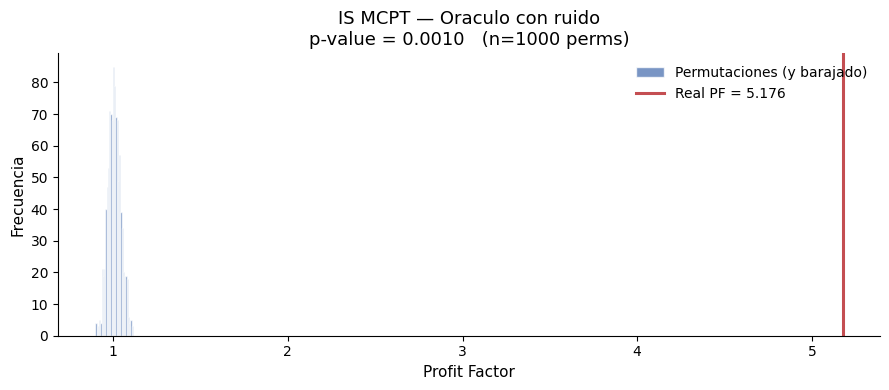

In [75]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_mcpt(is_results['oracle'], 'IS MCPT — Oraculo con ruido', ax=ax)
plt.tight_layout(); plt.show()

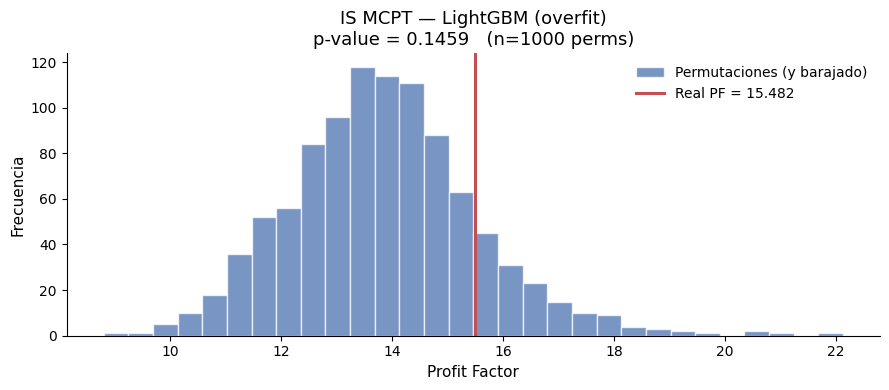

In [76]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_mcpt(is_results['lgbm'], 'IS MCPT — LightGBM (overfit)', ax=ax)
plt.tight_layout(); plt.show()

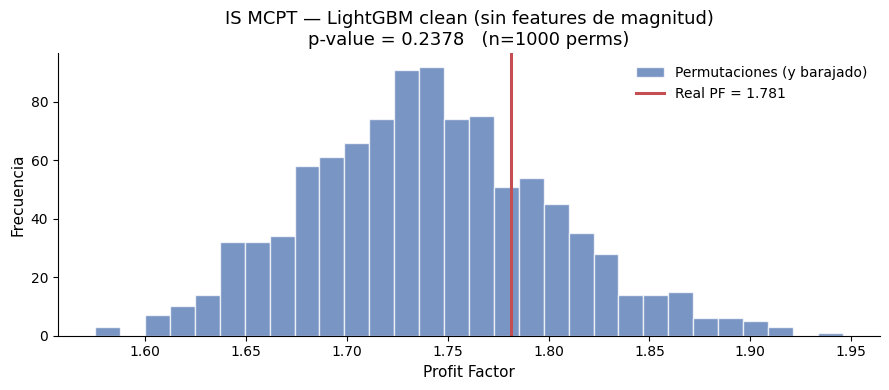

In [77]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_mcpt(is_results['lgbm_clean'], 'IS MCPT — LightGBM clean (sin features de magnitud)', ax=ax)
plt.tight_layout(); plt.show()

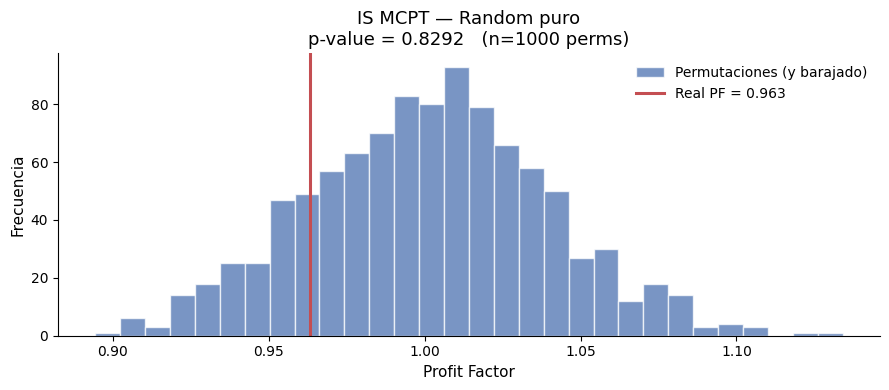

In [78]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_mcpt(is_results['random'], 'IS MCPT — Random puro', ax=ax)
plt.tight_layout(); plt.show()

### Walk-Forward OOS

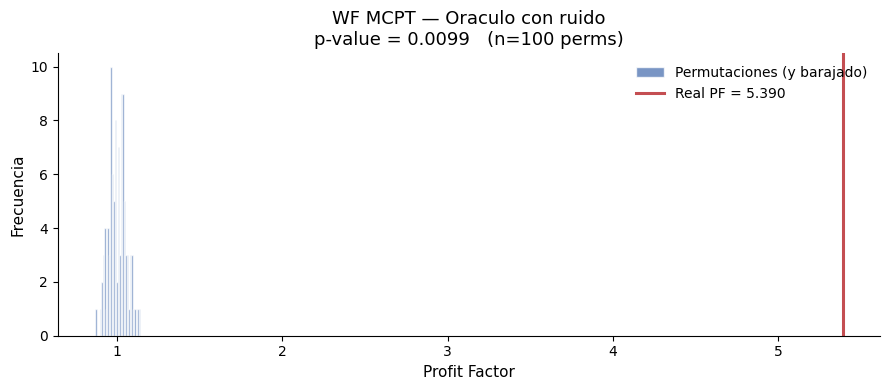

In [79]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_mcpt(wf_results['oracle'], 'WF MCPT — Oraculo con ruido', ax=ax)
plt.tight_layout(); plt.show()

In [80]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_mcpt(wf_results['lgbm'], 'WF MCPT — LightGBM (overfit)', ax=ax)
plt.tight_layout(); plt.show()

KeyError: 'lgbm'

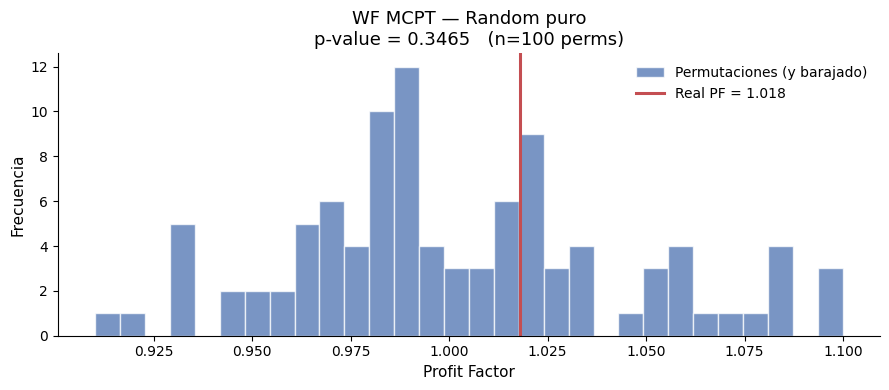

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_mcpt(wf_results['random'], 'WF MCPT — Random puro', ax=ax)
plt.tight_layout(); plt.show()

## Equity curves: real vs permutaciones

Para cada modelo, ploteamos la curva de retorno acumulado de la corrida real (rojo) contra todas las trayectorias bajo H0 (gris). No agrega informacion estadistica sobre la del histograma, pero es la representacion visual mas intuitiva del experimento: la curva real deberia destacarse del "abanico" gris si hay senal.

In [ ]:
# Plot: curva real en rojo, permutaciones en gris semi-transparente sobre fondo blanco.
# Si se pasa train_window (caso WF), las primeras train_window barras son comunes
# a todas las permutaciones (no se permuta esa zona). Una linea vertical marca
# la transicion train -> OOS.

def plot_equity_curves(curve_real, perm_curves, index, title, train_window=None):
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    min_len = min(len(curve_real), min(len(c) for c in perm_curves))
    idx = index[:min_len]

    for c in perm_curves:
        ax.plot(idx, c[:min_len], color='gray', alpha=0.12, linewidth=0.7)

    ax.plot(idx, curve_real[:min_len], color=_COLORS[3], linewidth=2.0, label='Real', zorder=10)

    if train_window is not None and 0 < train_window < min_len:
        oos_start = idx[train_window]
        ax.axvline(oos_start, color='black', linewidth=1.0, linestyle='--', alpha=0.6, zorder=5)
        ax.text(oos_start, ax.get_ylim()[1], '  inicio OOS',
                ha='left', va='top', fontsize=9, alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('PnL acumulado (log)')
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    ax.legend(frameon=False, loc='upper left')
    ax.grid(False)
    plt.tight_layout()
    plt.show()

### In-Sample

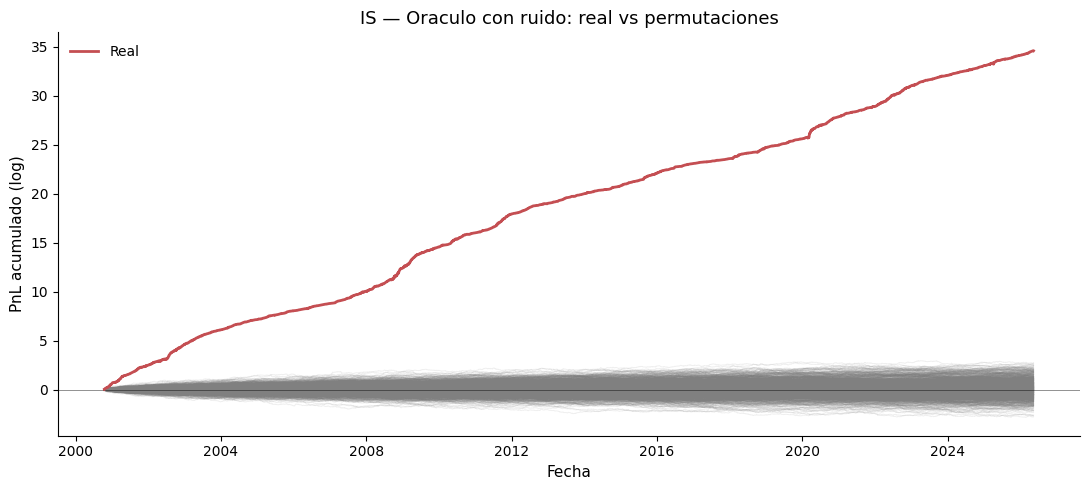

In [ ]:
r = is_results['oracle']
plot_equity_curves(r['curve_real'], r['perm_curves'], r['index'],
                   'IS — Oraculo con ruido: real vs permutaciones')

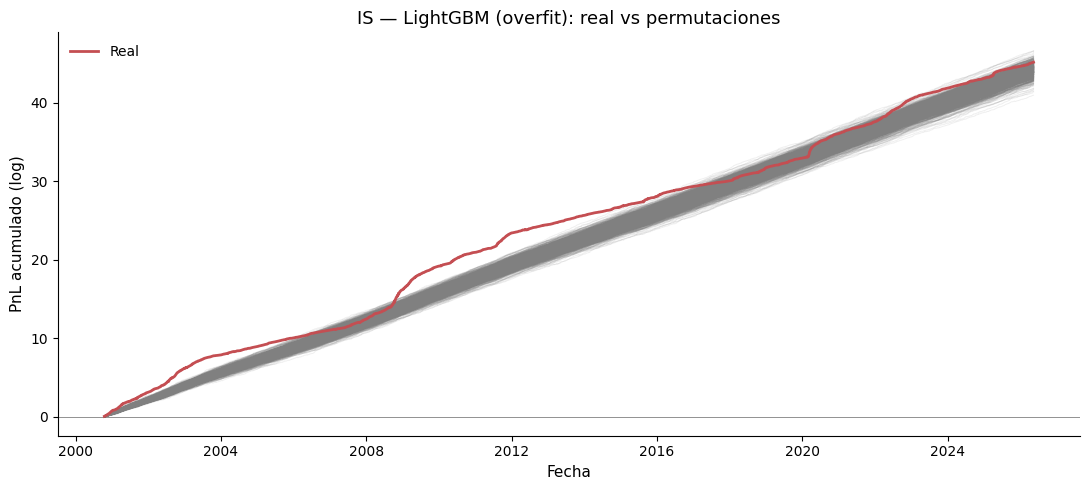

In [ ]:
r = is_results['lgbm']
plot_equity_curves(r['curve_real'], r['perm_curves'], r['index'],
                   'IS — LightGBM (overfit): real vs permutaciones')

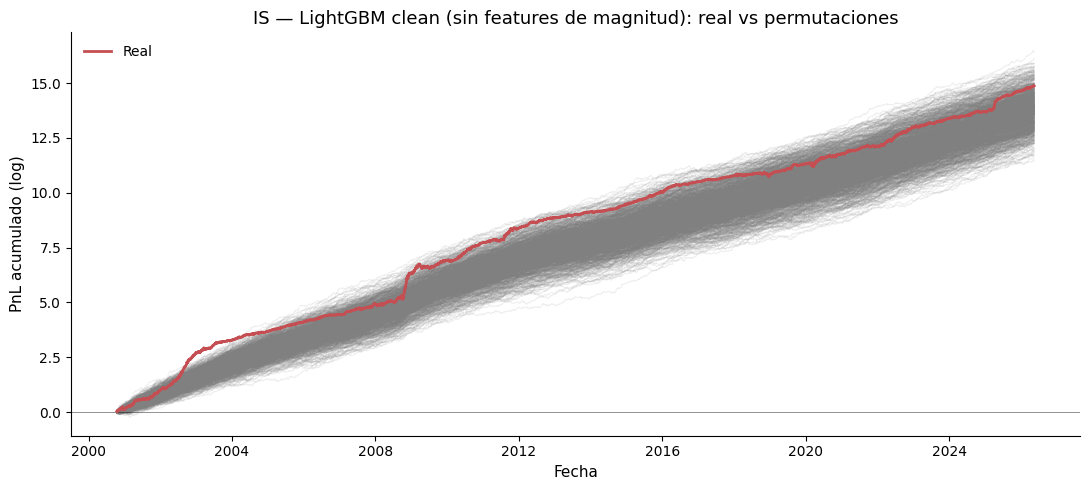

In [ ]:
r = is_results['lgbm_clean']
plot_equity_curves(r['curve_real'], r['perm_curves'], r['index'],
                   'IS — LightGBM clean (sin features de magnitud): real vs permutaciones')

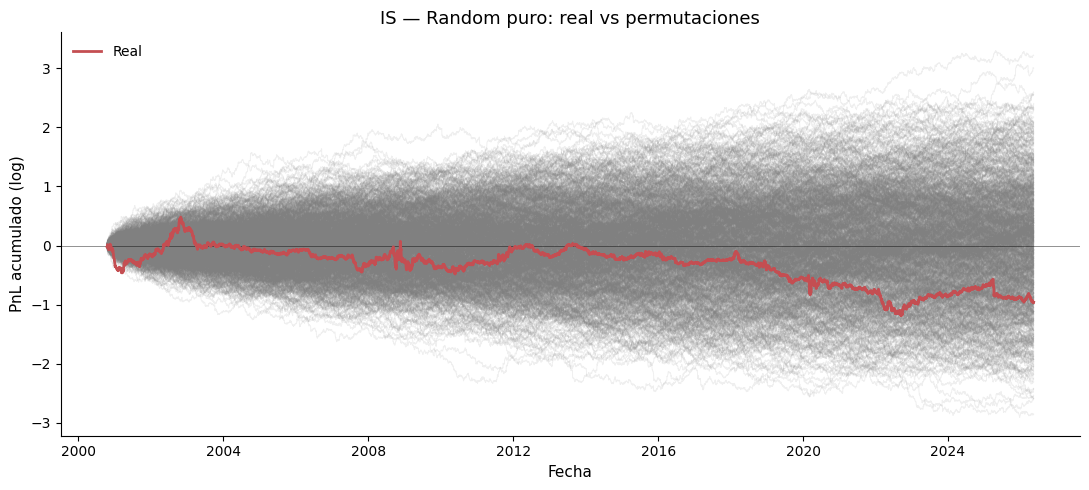

In [ ]:
r = is_results['random']
plot_equity_curves(r['curve_real'], r['perm_curves'], r['index'],
                   'IS — Random puro: real vs permutaciones')

### Walk-Forward OOS

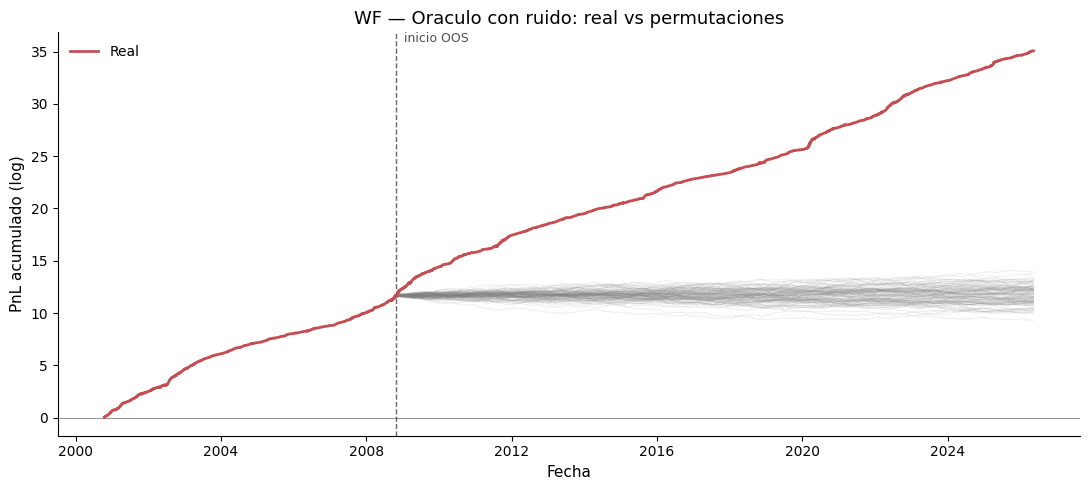

In [ ]:
r = wf_results['oracle']
plot_equity_curves(r['curve_real'], r['perm_curves'], r['index'],
                   'WF — Oraculo con ruido: real vs permutaciones',
                   train_window=r['train_window'])

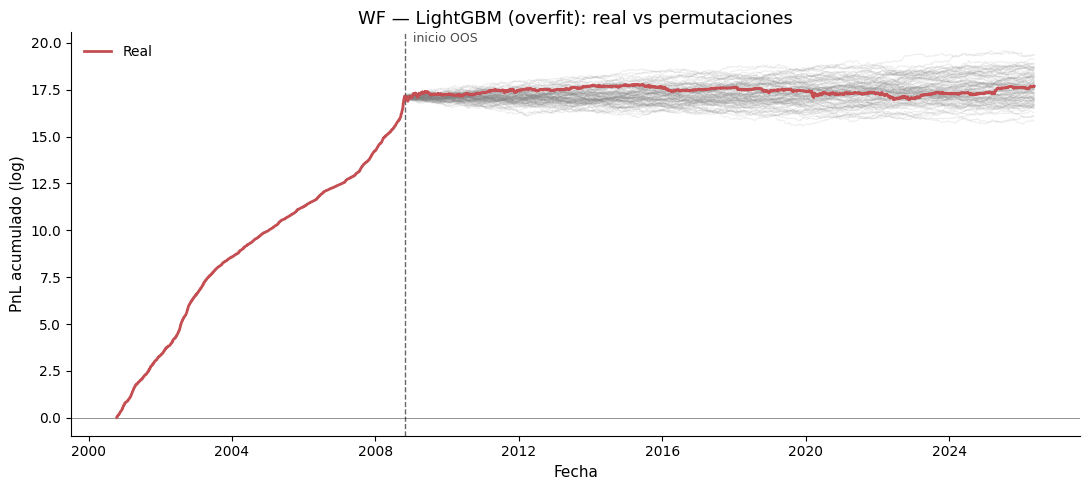

In [ ]:
r = wf_results['lgbm']
plot_equity_curves(r['curve_real'], r['perm_curves'], r['index'],
                   'WF — LightGBM (overfit): real vs permutaciones',
                   train_window=r['train_window'])

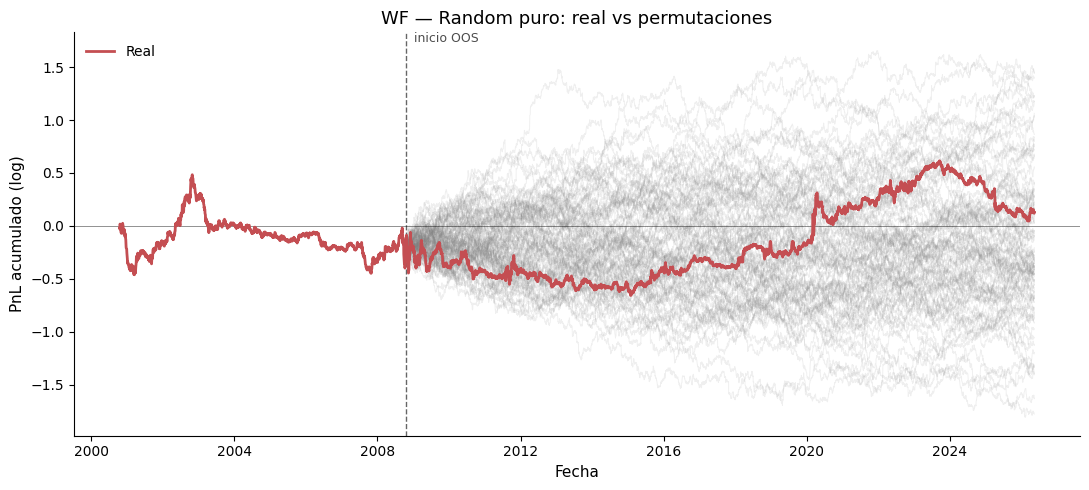

In [ ]:
r = wf_results['random']
plot_equity_curves(r['curve_real'], r['perm_curves'], r['index'],
                   'WF — Random puro: real vs permutaciones',
                   train_window=r['train_window'])

## Tabla resumen

In [ ]:
rows = []
for name in ['oracle', 'lgbm', 'lgbm_clean', 'random']:
    row = {
        'Modelo'     : name,
        'PF real IS' : is_results[name]['real_pf'],
        'p-value IS' : is_results[name]['p_value'],
    }
    # WF solo corre para los modelos que existen en wf_results
    if name in wf_results:
        row['PF real WF'] = wf_results[name]['real_pf']
        row['p-value WF'] = wf_results[name]['p_value']
    else:
        row['PF real WF'] = np.nan
        row['p-value WF'] = np.nan
    rows.append(row)
summary = pd.DataFrame(rows).set_index('Modelo')
summary.round(4)

,PF real IS,p-value IS,PF real WF,p-value WF
Modelo,,,,
oracle,5.1763,0.0010,5.3898,0.0099
lgbm,16.1297,0.0909,1.0347,0.4356
lgbm_clean,1.8200,0.0979,NaN,NaN
random,0.9633,0.8292,1.0179,0.3465


## Interpretacion

Lo que esperamos ver (y lo que confirma que el MCPT funciona):

- **Oraculo**: p-value chico en IS **y** en WF. El test detecta la senal real que pusimos a mano.
- **LightGBM overfit**: p-value muy chico IS (el modelo se ajusta hasta al ruido y vuelve a hacerlo con cada `y` permutado, pero el PF real es muy alto), p-value alto en WF (la "magia" desaparece OOS). Este es el caso pedagogico clave: **un backtest in-sample espectacular puede no significar nada**.
- **Random**: p-value alto y aproximadamente uniforme tanto en IS como en WF. El test correctamente no encuentra senal donde no la hay.

El MCPT no te dice si tu modelo es bueno en terminos absolutos; te dice si su performance es **distinguible** de la que obtendrias con un modelo sin senal entrenado sobre datos sin link X->y. Esa es exactamente la pregunta correcta para detectar overfitting.